# 14 · From offline analysis to causal replay

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Process recorded EEG in chunks with persistent filter state and verify that chunking does not change the causal result.

**Data:** Recorded EEGBCI stream; no live hardware

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

An online decoder has access only to samples already acquired. A causal IIR filter follows $y[n]=\sum_k b_kx[n-k]-\sum_{k=1}a_ky[n-k]$. Its state summarizes past inputs and outputs; resetting that state at every chunk causes repeated transients.

Total response latency includes acquisition buffering, filter delay, feature-window duration, inference and actuator delay: $T_{total}\approx T_{buffer}+T_{filter}+T_{window}+T_{compute}+T_{actuator}$. A fast classifier cannot compensate for a four-second feature window. Offline zero-phase results are not online performance estimates.

The replay below uses no real-time clock, hardware connection or robot. It verifies the signal-processing implementation against a single-pass causal reference. A deployed BCI additionally needs synchronized event timestamps, calibration, an idle/reject state, drift monitoring and an independent stop control.

## Load a recorded stream
Keep the raw recording in its native sampling rate and inspect one channel for the numerical check.

In [2]:
from mne.datasets import eegbci
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
eegbci.standardize(raw)
raw.set_montage('standard_1005')
print(raw)
print('Channel types:', set(raw.get_channel_types()))

stream=raw.get_data(picks=['C3'])[0]
fs=raw.info['sfreq']
sos=signal.butter(4,[8,30],btype='bandpass',fs=fs,output='sos')

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_418230/1120295533.py:5: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


## Replay with persistent state
The equality check would fail if the state were reset inside the loop.

Maximum chunking error: 0.0


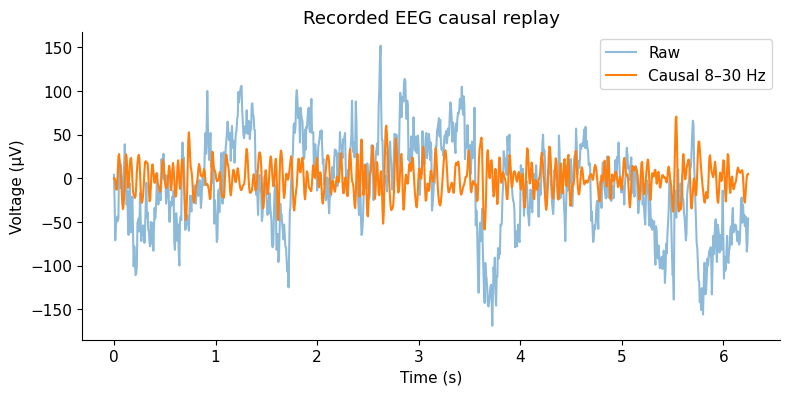

In [3]:
reference=signal.sosfilt(sos,stream)
state=np.zeros((sos.shape[0],2))
chunks=[]
for start in range(0,len(stream),32):
    filtered,state=signal.sosfilt(sos,stream[start:start+32],zi=state)
    chunks.append(filtered)
replay=np.concatenate(chunks)
assert np.allclose(replay,reference,rtol=1e-10,atol=1e-14)
print('Maximum chunking error:',np.max(abs(replay-reference)))
fig,ax=plt.subplots()
time=np.arange(len(stream))/fs
ax.plot(time[:1000],stream[:1000]*1e6,label='Raw',alpha=.5)
ax.plot(time[:1000],replay[:1000]*1e6,label='Causal 8–30 Hz')
ax.set(xlabel='Time (s)',ylabel='Voltage (µV)',title='Recorded EEG causal replay')
ax.legend(); plt.show()

## Measure feature availability
Each feature uses a trailing window only. This is a feature stream, not a validated online classifier.

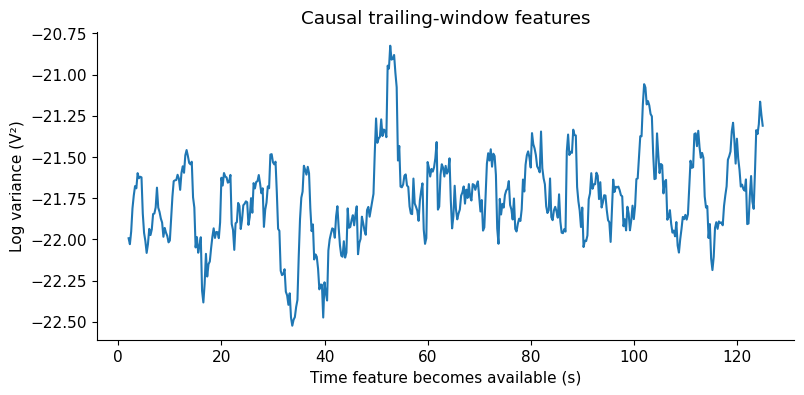

Window duration: 2.0 s; update interval: 0.25 s


In [4]:
window=int(2*fs); hop=int(.25*fs)
ends=np.arange(window,len(replay)+1,hop)
log_power=np.array([np.log(np.var(replay[end-window:end])+1e-30) for end in ends])
fig,ax=plt.subplots(); ax.plot((ends-1)/fs,log_power)
ax.set(xlabel='Time feature becomes available (s)',ylabel='Log variance (V²)',title='Causal trailing-window features')
plt.show()
print('Window duration:',window/fs,'s; update interval:',hop/fs,'s')

## Exercises and checks
1. Reset state inside each chunk and quantify the error.
2. Why must a model be calibrated using the same causal filter as deployment?
3. Design an idle-state dataset; left/right accuracy alone cannot measure false activations at rest.
4. Define false commands per minute, rejection rate and end-to-end latency for an assistive application.

## Next steps and sources
[SciPy SOS filtering](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sosfilt.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.